In [52]:
import tensorflow as tf
import numpy as np
from tqdm import tqdm
import time
import os
import os
import tensorflow as tf
from tensorflow.keras import mixed_precision

tf.keras.mixed_precision.set_global_policy('float32')

# Note: Your model will now output float16. 
# Ensure your last layer is float32 for stability:
# self.out = tf.keras.layers.Dense(num_classes, dtype='float32')

# Standard Conda path for libdevice
conda_cuda_path = os.path.join(os.environ.get('CONDA_PREFIX', ''), "Library", "bin")
if os.path.exists(conda_cuda_path):
    os.environ['XLA_FLAGS'] = f"--xla_gpu_cuda_data_dir={conda_cuda_path}"
    print(f"XLA Path set to: {conda_cuda_path}")

# EMERGENCY BYPASS: If it still fails, disable JIT for now. 
# It will be slightly slower, but it will NOT crash.
USE_JIT = False

import os
os.environ['XLA_FLAGS'] = '--xla_gpu_cuda_data_dir="C:/Users/caspe/anaconda3/envs/SPIKEDETEC/Library/bin"'

XLA Path set to: C:\Users\caspe\anaconda3\envs\SPIKEDETEC\Library\bin


In [51]:
# 1. Load MNIST
(x_all, y_all), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# 2. Flatten and Normalize (Standard step)
x_all = x_all.reshape(-1, 784).astype('uint8') / 255.0
x_test = x_test.reshape(-1, 784).astype('uint8') / 255.0

# 3. Create FIXED Permutation (The "p" in pMNIST)
rng = np.random.RandomState(42)
perm = rng.permutation(784)

x_all = x_all[:, perm]
x_test = x_test[:, perm]

# --- NEW: Train/Val Split (90% Train, 10% Val) ---
from sklearn.model_selection import train_test_split
x_train, x_val, y_train, y_val = train_test_split(
    x_all, y_all, test_size=0.1, random_state=42, stratify=y_all
)

# 4. Reshape to [Batch, Time, Channels] for your RNN
x_train = x_train[:, :, np.newaxis]
x_val   = x_val[:, :, np.newaxis]
x_test  = x_test[:, :, np.newaxis]

# 5. Labels to int32
y_train = y_train.astype('int32')
y_val   = y_val.astype('int32')
y_test  = y_test.astype('int32')

# 6. Build datasets
train_ds = tf.data.Dataset.from_tensor_slices((x_train, y_train)).shuffle(10000).batch(256)
val_ds   = tf.data.Dataset.from_tensor_slices((x_val, y_val)).batch(256)
test_ds  = tf.data.Dataset.from_tensor_slices((x_test, y_test)).batch(256)

print(f"pMNIST Ready. Train: {x_train.shape}, Val: {x_val.shape}, Test: {x_test.shape}")

pMNIST Ready. Train: (54000, 784, 1), Val: (6000, 784, 1), Test: (10000, 784, 1)


##  Global field block

In [50]:
import tensorflow as tf
import numpy as np
from tqdm import tqdm
import scipy.linalg

# --- 1. THE ODE-BASED BIOLOGICAL PROXY CELL ---
class IsolatedGlobalFieldCell(tf.keras.layers.Layer):
    def __init__(self, units=128, strength=0.1, lambda_slow=0.01, alpha=0.3, **kwargs):
        super().__init__(**kwargs)
        self.units = units
        self.state_size = [units, units] # [h, G]
        self.strength = strength
        self.lambda_slow = lambda_slow
        self.alpha = alpha

    def build(self, input_shape):
        # Standard initialization - no bias toward rank expansion
        self.w_in = self.add_weight(shape=(input_shape[-1], self.units), 
                                    initializer="glorot_uniform", name="w_in")
        self.w_rec = self.add_weight(shape=(self.units, self.units), 
                                     initializer=tf.keras.initializers.Orthogonal(gain=1.0), 
                                     name="w_rec")
        self.bias = self.add_weight(shape=(self.units,), 
                                    initializer="zeros", name="bias")

    def call(self, inputs, states):
        prev_h = states[0]
        prev_G = states[1]
        
        # 1. The Raw Global Field (Shifted Cross-Talk)
        # Just simple population feedback.
        half = self.units // 2
        shifted_h = tf.concat([prev_h[:, half:], prev_h[:, :half]], axis=1)
        
        # ODE update for the field
        new_G = (1.0 - self.lambda_slow) * prev_G + self.lambda_slow * shifted_h
        
        # Field Normalization - CRITICAL to keep the comparison fair 
        # so 'strength' means the same thing across epochs.
        G_norm = (new_G - tf.reduce_mean(new_G, axis=-1, keepdims=True)) / (tf.math.reduce_std(new_G, axis=-1, keepdims=True) + 1e-6)
        
        # 2. Linear Integration
        z_in = tf.matmul(inputs, self.w_in)
        z_rec = tf.matmul(prev_h, self.w_rec)
        
        # 3. MODULATION (The only variable)
        # When strength=0 (Passive), this is exactly 1.0 (No effect)
        field_effect = 1.0 + (self.strength * tf.tanh(G_norm))
        h_candidate = (z_in + z_rec) * field_effect
        
        # 4. Naked Activation
        h_activated = tf.nn.leaky_relu(h_candidate + self.bias, alpha=0.1)
        
        # 5. Temporal Leak (Neurons)
        h = (self.alpha * prev_h) + (1.0 - self.alpha) * h_activated
        
        return h, [h, new_G]

# --- 2. THE HIERARCHICAL NETWORK ---
class HierarchicalGlobalNet(tf.keras.Model):
    def __init__(self, hidden=128, num_classes=10, strength=0.1, lambda_slow=0.01, use_lfp=True):
        super().__init__()
        self.use_lfp = use_lfp
        # We set return_state=True to ensure we can handle the internal states
        self.rnn1 = tf.keras.layers.RNN(
            IsolatedGlobalFieldCell(hidden, strength=strength, lambda_slow=lambda_slow), 
            return_sequences=True
        )
        self.rnn2 = tf.keras.layers.RNN(
            IsolatedGlobalFieldCell(hidden, strength=strength, lambda_slow=lambda_slow), 
            return_sequences=True
        )
        self.out = tf.keras.layers.Dense(num_classes, dtype='float32')

    def call(self, x, training=False):
        # RNN layer returns the sequence directly if return_state=False (default)
        h1_seq = self.rnn1(x, training=training)
        h2_seq = self.rnn2(h1_seq, training=training)
        
        logits = self.out(h2_seq[:, -1, :])
        return logits, h2_seq if self.use_lfp else None

# --- 3. TRAINING & METRICS ---
@tf.function(jit_compile=False)
def train_step(x, y, model, optimizer, loss_fn, train_acc_metric):
    with tf.GradientTape() as tape:
        logits, h_seq = model(x, training=True) 
        loss = loss_fn(y, logits)
        scaled_loss = optimizer.get_scaled_loss(loss)

    h_final = h_seq[:, -1, :] 
    live_var = tf.reduce_mean(tf.math.reduce_std(h_final, axis=-1))

    grads = tape.gradient(scaled_loss, model.trainable_variables)
    if isinstance(optimizer, tf.keras.mixed_precision.LossScaleOptimizer):
        grads = optimizer.get_unscaled_gradients(grads)
    
    grads = [tf.clip_by_norm(g, 1.0) for g in grads]
    optimizer.apply_gradients(zip(grads, model.trainable_variables))
    
    train_acc_metric.update_state(y, logits)
    return loss, live_var

def train_model_tf(model, train_data, val_data, epochs=5, lr=1e-3):
    optimizer = tf.keras.mixed_precision.LossScaleOptimizer(tf.keras.optimizers.Adam(learning_rate=lr))
    loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
    history = {"loss": [], "acc": [], "hidden_metrics": []}

    for epoch in range(epochs):
        train_acc_metric = tf.keras.metrics.SparseCategoricalAccuracy()
        pbar = tqdm(train_data, desc=f"Epoch {epoch+1}")
        
        for x_batch, y_batch in pbar:
            loss_val, live_var = train_step(x_batch, y_batch, model, optimizer, loss_fn, train_acc_metric)
            pbar.set_postfix({"loss": f"{loss_val.numpy():.4f}", "acc": f"{train_acc_metric.result().numpy():.4f}", "rank_v": f"{live_var.numpy():.4f}"})

        for x_v, y_v in val_data.take(1):
            logits_v, h_seq_v = model(x_v, training=False)
            metrics = compute_lfp_metrics(h_seq_v.numpy(), strength=model.rnn1.cell.strength)
            val_acc = np.mean(np.argmax(logits_v.numpy(), axis=-1) == y_v.numpy())
            history["loss"].append(loss_val.numpy())
            history["acc"].append(val_acc)
            history["hidden_metrics"].append(metrics)
            
            print(f" [Snapshot] Val_Acc: {val_acc:.4f} | Rank: {metrics['effective_rank']:.2f} | Sync: {metrics['synchrony']:.3f} | Intf: {metrics['interference']:.2f}")
            
    return history

def compute_lfp_metrics(h_seq_np, strength=0.0):
    h_final = np.nan_to_num(h_seq_np[:, -1, :])
    
    # 1. Effective Rank
    s = scipy.linalg.svdvals(h_final)
    p = s / (np.sum(s) + 1e-10)
    eff_rank = np.exp(-np.sum(p * np.log(p + 1e-10)))

    # 2. Synchrony
    corr_matrix = np.nan_to_num(np.corrcoef(h_final.T))
    sync = (np.sum(np.abs(corr_matrix)) - h_final.shape[1]) / (h_final.shape[1]**2 - h_final.shape[1])

    # 3. Autocorrelation (A-Corr)
    h_t, h_prev = h_seq_np[:, 1:, :], h_seq_np[:, :-1, :]
    a_corr = np.mean([np.corrcoef(h_t[0, i], h_prev[0, i])[0, 1] for i in range(min(5, h_t.shape[1]))])

    # 4. Log Interference (Intf)
    modulation_range = np.abs(strength) 
    intf = np.log10(modulation_range + 1e-8)

    # 5. Entropy
    counts, _ = np.histogram(h_final, bins=50)
    probs = counts / (np.sum(counts) + 1e-10)
    entropy = -np.sum(probs * np.log2(probs + 1e-10))

    return {
        "effective_rank": float(eff_rank), "synchrony": float(sync),
        "entropy": float(entropy), "a_corr": float(np.nan_to_num(a_corr)),
        "interference": float(intf)
    }

## Training

In [33]:
import gc # For clearing VRAM

# --- 1. DATA SUBSETTING & PREP ---
DATA_PERCENT = 0.05  
BATCH_SIZE = 128     
EPOCHS = 6

num_train = int(len(x_train) * DATA_PERCENT)
num_val   = int(len(x_val) * DATA_PERCENT)
num_test  = int(len(x_test) * DATA_PERCENT)

train_ds_subset = tf.data.Dataset.from_tensor_slices((x_train[:num_train], y_train[:num_train])) \
    .shuffle(5000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

val_ds_subset = tf.data.Dataset.from_tensor_slices((x_val[:num_val], y_val[:num_val])) \
    .batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

test_ds_subset = tf.data.Dataset.from_tensor_slices((x_test[:num_test], y_test[:num_test])) \
    .batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print(f"Test Run Ready: Samples -> Train: {num_train}, Val: {num_val}")

# --- 2. THE UPDATED TRAIN_MODEL_TF FUNCTION ---
def train_model_tf(model, train_data, val_data, epochs=2, lr=1e-3):
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr)
    loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
    
    @tf.function(jit_compile=False)
    def local_train_step(x, y):
        with tf.GradientTape() as tape:
            logits, h_seq = model(x, training=True)
            loss = loss_fn(y, logits)

        # Calculate live rank proxy for the tqdm bar
        h_final = h_seq[:, -1, :]
        live_var = tf.reduce_mean(tf.math.reduce_std(h_final, axis=-1))

        grads = tape.gradient(loss, model.trainable_variables)
        grads = [tf.clip_by_norm(g, 1.0) for g in grads]
        optimizer.apply_gradients(zip(grads, model.trainable_variables))
        
        # RETURNS 3 VALUES
        return loss, logits, live_var

    # 1. Warm-up (Fixed unpacking)
    print("Initializing Model...")
    for x_init, y_init in train_data.take(1):
        _, _, _ = local_train_step(x_init[:1], y_init[:1])
    
    history = {"loss": [], "acc": [], "hidden_metrics": []}
    
    # 2. Training Loop
    for epoch in range(epochs):
        train_acc_metric = tf.keras.metrics.SparseCategoricalAccuracy()
        pbar = tqdm(train_data, desc=f"Epoch {epoch+1}")
        
        for x_batch, y_batch in pbar:
            
            loss_val, logits, var_val = local_train_step(x_batch, y_batch)
            
            train_acc_metric.update_state(y_batch, logits)
            
            # Update TQDM with the live rank variance
            pbar.set_postfix({
                "loss": f"{loss_val.numpy():.4f}", 
                "acc": f"{train_acc_metric.result().numpy():.4f}",
                "rank_v": f"{var_val.numpy():.4f}"
            })

        # 3. Validation Snapshot
        for x_v, y_v in val_data.take(1):
            logits_v, h_seq_v = model(x_v, training=False)
            metrics = compute_lfp_metrics(h_seq_v.numpy())
            val_acc = np.mean(np.argmax(logits_v.numpy(), axis=-1) == y_v.numpy())
            
            history["loss"].append(loss_val.numpy())
            history["acc"].append(val_acc)
            history["hidden_metrics"].append(metrics)
            
            print(f" [Snapshot] Val_Acc: {val_acc:.4f} | Rank: {metrics['effective_rank']:.2f} | Sync: {metrics['synchrony']:.3f}")
            
    return history

# --- 3. EXECUTION BLOCK ---

# PHASE 1: GLOBAL FIELD (Now with ODE Slowness)
print("\n[Phase 1] Training ODE Global Field Model...")

model_global = HierarchicalGlobalNet(hidden=8, strength=-0.5, lambda_slow=0.01, use_lfp=True)
history_lfp = train_model_tf(model_global, train_ds_subset, val_ds_subset, epochs=EPOCHS)

# VRAM Management: Clear memory
print("\nCleaning VRAM for next model...")
tf.keras.backend.clear_session()
gc.collect()

# PHASE 2: PASSIVE BASELINE
print("\n[Phase 2] Training Passive Baseline...")
# Strength 0.0 effectively disables the Modulatory Field interaction
model_passive = HierarchicalGlobalNet(hidden=8, strength=0.0, use_lfp=True)
history_base = train_model_tf(model_passive, train_ds_subset, val_ds_subset, epochs=EPOCHS)

Test Run Ready: Samples -> Train: 2700, Val: 300

[Phase 1] Training ODE Global Field Model...
Initializing Model...


Epoch 1: 100%|██████████| 22/22 [00:51<00:00,  2.36s/it, loss=2.2677, acc=0.1085, rank_v=0.1343]


 [Snapshot] Val_Acc: 0.0938 | Rank: 2.46 | Sync: 0.607


Epoch 2: 100%|██████████| 22/22 [00:53<00:00,  2.44s/it, loss=2.2715, acc=0.1200, rank_v=0.1327]


 [Snapshot] Val_Acc: 0.0859 | Rank: 2.66 | Sync: 0.600


...

 [Snapshot] Val_Acc: 0.2031 | Rank: 1.19 | Sync: 0.975


Epoch 5: 100%|██████████| 22/22 [00:48<00:00,  2.20s/it, loss=2.1747, acc=0.1815, rank_v=0.1961]


 [Snapshot] Val_Acc: 0.2031 | Rank: 3.38 | Sync: 0.448


Epoch 6: 100%|██████████| 22/22 [00:51<00:00,  2.33s/it, loss=2.2819, acc=0.1830, rank_v=0.1545]


 [Snapshot] Val_Acc: 0.2031 | Rank: 3.34 | Sync: 0.576


In [47]:
def print_history_summary(history, model, model_name="Model", test_acc=None, data_percent=DATA_PERCENT):
    total_params = model.count_params()
    
    # REACHING INTO THE CELL FOR THE REAL STRENGTH
    try:
        # Check rnn1 -> layer -> cell
        cell = model.rnn1.cell
        # If it's a standard RNN wrapper, we need to check if it's the layer property
        if hasattr(cell, 'layers'): 
             target_cell = cell.layers[0]
        else:
             target_cell = cell
             
        hidden_size = target_cell.units
        field_w = target_cell.strength
        l_slow = target_cell.lambda_slow
    except Exception as e:
        # Fallback if the path above is slightly different in your env
        hidden_size = "N/A"
        field_w = 0.0
        l_slow = 0.0

    print(f"\n{'='*140}")
    print(f" DATA LOG: {model_name}")
    # Included DATA_PERCENT here
    print(f" CONFIG: Hidden: {hidden_size} | Params: {total_params:,} | Field Weight: {field_w:.4f} | Lambda Slow (τ): {l_slow:.4f} | Data: {data_percent*100:.1f}%")
    print(f"{'='*140}")
    
    # 2. Table Headers
    header = f"{'Epoch':<6} | {'Loss':<7} | {'Val-Acc%':<8} | {'Rank':<6} | {'Sync':<6} | {'Entrp':<6} | {'A-Corr':<7} | {'Intf':<6} | {'F-Wgt':<6}"
    print(header)
    print(f"{'-'*140}")

    # 3. Epoch-by-Epoch Data
    for i in range(len(history['loss'])):
        loss = history['loss'][i]
        acc  = history['acc'][i] 
        
        dyn = history['hidden_metrics'][i]
        rank     = dyn.get('effective_rank', 0)
        sync     = dyn.get('synchrony', 0)
        entropy  = dyn.get('entropy', 0)
        autocorr = dyn.get('a_corr', 0)
        interf   = dyn.get('interference', 0)
        
        current_f_wgt = history.get('field_weights', [field_w]*len(history['loss']))[i]

        print(f"{i+1:<6} | {loss:<7.3f} | {acc*100:<8.2f} | {rank:<6.2f} | {sync:<6.3f} | {entropy:<6.2f} | {autocorr:<7.3f} | {interf:<6.3f} | {current_f_wgt:<6.3f}")
    
    # 4. Final Conclusion Block
    final_val_acc = history['acc'][-1] * 100
    test_str = f"{test_acc*100:.2f}%" if test_acc is not None else "N/A"
    
    print(f"{'-'*140}")
    print(f" FINAL PERFORMANCE: Validation Acc: {final_val_acc:.2f}% | TEST ACCURACY: {test_str}")
    print(f" FINAL DYNAMICS   : Rank: {rank:.2f} | Entropy: {entropy:.2f} | Synchrony: {sync:.3f}")
    print(f"{'='*140}\n")

# --- Usage (Post-Evaluation) ---

# 1. Evaluate models on the actual Test Set
print("Final Evaluation on Test Set...")
#test_acc_lfp = np.mean([np.mean(np.argmax(model_global(x, training=False)[0].numpy(), axis=-1) == y.numpy()) for x, y in test_ds_subset])
#test_acc_base = np.mean([np.mean(np.argmax(model_passive(x, training=False)[0].numpy(), axis=-1) == y.numpy()) for x, y in test_ds_subset])

# 2. Print summaries with the test score
print_history_summary(history_lfp, model_global, "HIERARCHICAL GLOBAL FIELD", test_acc=test_acc_lfp)
print_history_summary(history_base, model_passive, "PASSIVE BASELINE", test_acc=test_acc_base)

Final Evaluation on Test Set...

 DATA LOG: HIERARCHICAL GLOBAL FIELD
 CONFIG: Hidden: 8 | Params: 306 | Field Weight: -0.5000 | Lambda Slow (τ): 0.0100 | Data: 5.0%
Epoch  | Loss    | Val-Acc% | Rank   | Sync   | Entrp  | A-Corr  | Intf   | F-Wgt 
--------------------------------------------------------------------------------------------------------------------------------------------
1      | 2.268   | 9.38     | 2.46   | 0.607  | 4.21   | 0.765   | -8.000 | -0.500
2      | 2.271   | 8.59     | 2.66   | 0.600  | 4.22   | 0.752   | -8.000 | -0.500
3      | 2.257   | 7.81     | 2.90   | 0.580  | 4.37   | 0.762   | -8.000 | -0.500
4      | 2.250   | 8.59     | 2.63   | 0.565  | 4.23   | 0.788   | -8.000 | -0.500
5      | 2.297   | 10.16    | 2.60   | 0.552  | 4.08   | 0.813   | -8.000 | -0.500
6      | 2.182   | 7.81     | 2.57   | 0.543  | 4.03   | 0.824   | -8.000 | -0.500
----------------------------------------------------------------------------------------------------------------

 Plotting 7 total metrics (Performance + Hidden Dynamics)...


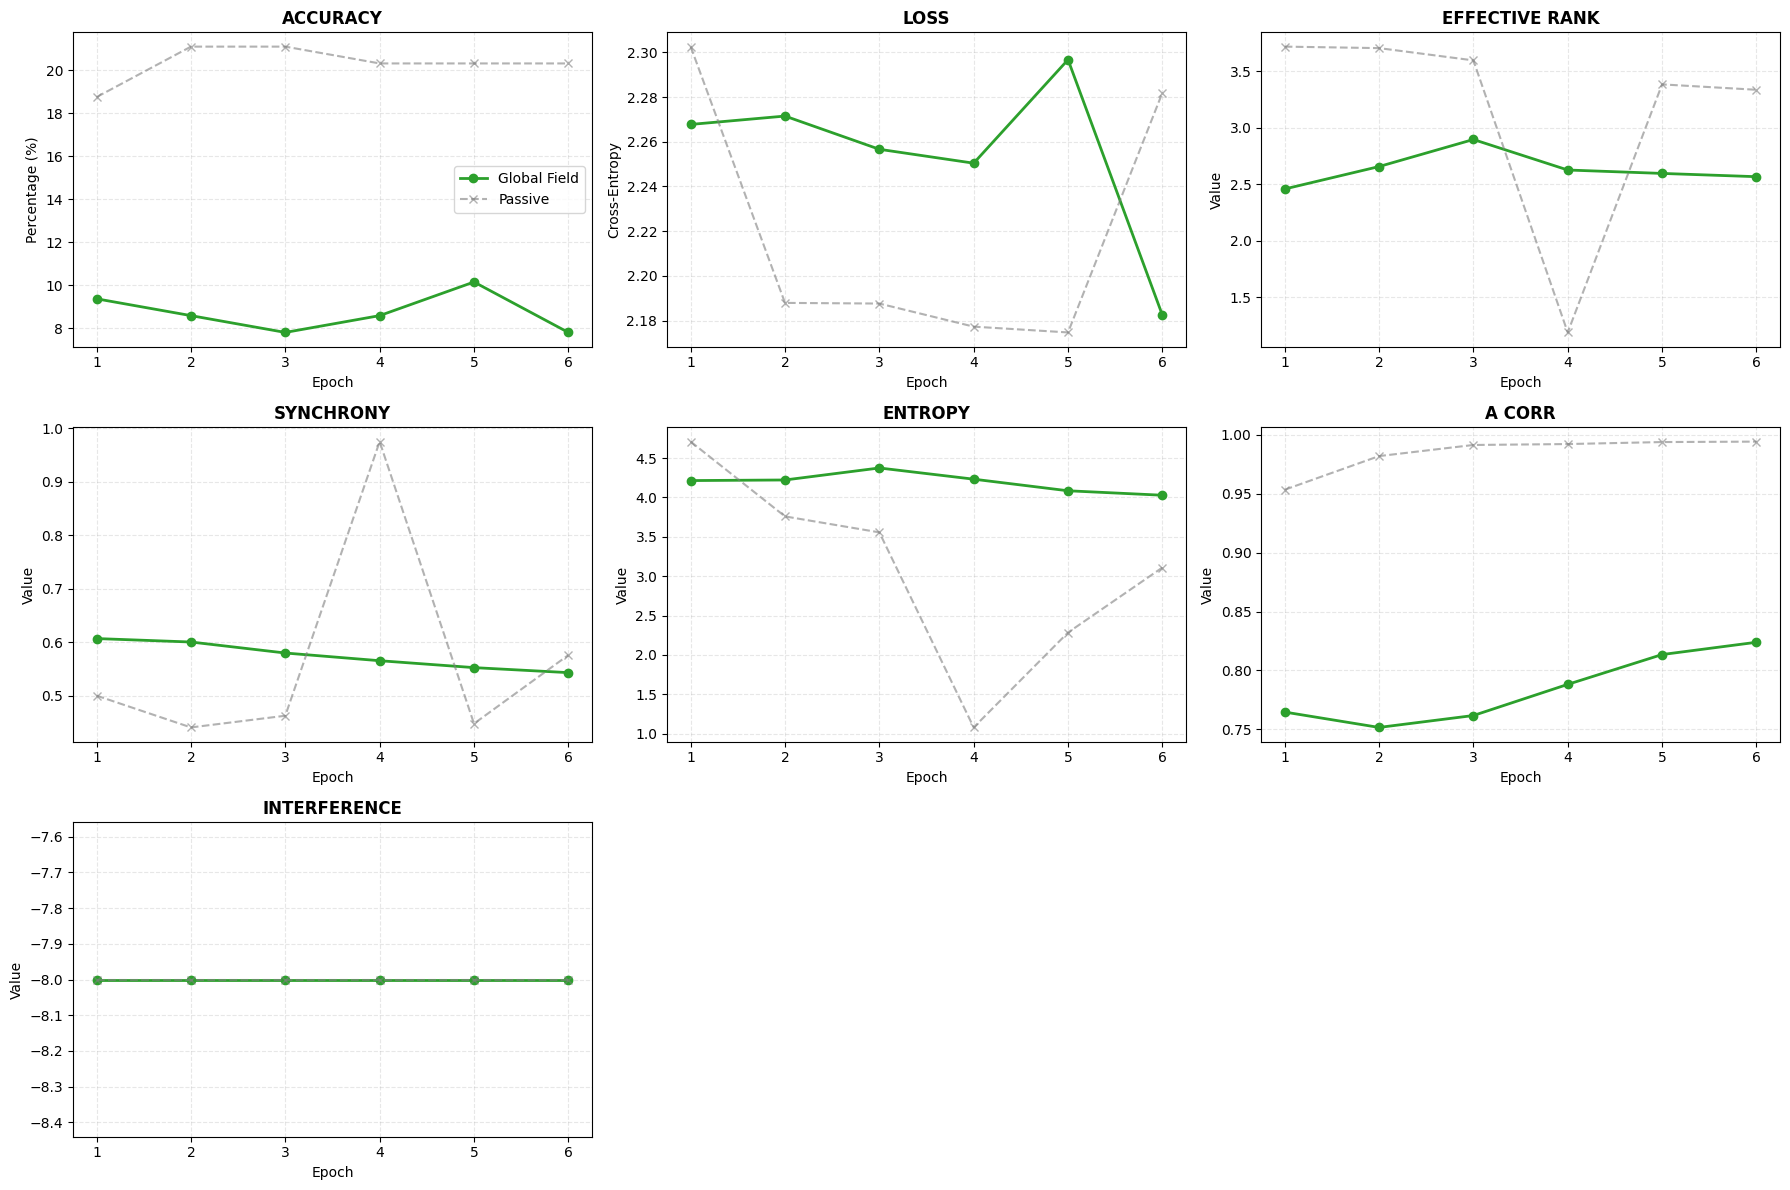

 Advanced metrics saved to 'thesis_hidden_dynamics_full.png'


In [35]:
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display, Image
import os

# Force inline for VS Code/Jupyter
%matplotlib inline 

def plot_advanced_metrics(history_lfp, history_base, folder=None):
    # 1. DATA PREP
    lfp_m = history_lfp.get("hidden_metrics", [])
    base_m = history_base.get("hidden_metrics", [])
    
    valid_lfp = [m for m in lfp_m if m is not None]
    if not valid_lfp:
        print(" No hidden metrics found in history_lfp.")
        return
    
    # Extract keys and set up Epochs
    metrics_keys = list(valid_lfp[0].keys())
    epochs = range(1, len(lfp_m) + 1)

    # 2. ADD ACCURACY AND LOSS TO THE GRID
    # We combine the standard training metrics with the hidden dynamics
    all_plot_keys = ["ACCURACY", "LOSS"] + metrics_keys
    n = len(all_plot_keys)
    cols = 3
    rows = (n + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(18, 4 * rows))
    axes = axes.flatten()

    print(f" Plotting {n} total metrics (Performance + Hidden Dynamics)...")

    for i, key in enumerate(all_plot_keys):
        if key == "ACCURACY":
            l_vals = [a * 100 for a in history_lfp["acc"]]
            b_vals = [a * 100 for a in history_base["acc"]]
            ylabel = "Percentage (%)"
        elif key == "LOSS":
            l_vals = history_lfp["loss"]
            b_vals = history_base["loss"]
            ylabel = "Cross-Entropy"
        else:
            # Extract biological metrics from the dictionaries
            l_vals = [m[key] if m and key in m else 0 for m in lfp_m]
            b_vals = [m[key] if m and key in m else 0 for m in base_m]
            ylabel = "Value"

        # Plotting
        axes[i].plot(epochs, l_vals, 'o-', label="Global Field", color='#2ca02c', linewidth=2)
        axes[i].plot(epochs, b_vals, 'x--', label="Passive", color='#7f7f7f', alpha=0.6)
        
        # Formatting
        title = key.replace('_', ' ').upper()
        axes[i].set_title(title, fontweight='bold', fontsize=12)
        axes[i].set_xlabel("Epoch")
        axes[i].set_ylabel(ylabel)
        axes[i].grid(True, alpha=0.3, linestyle='--')
        
        if i == 0: 
            axes[i].legend(loc='best')

    # 3. CLEANUP & SAVE
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    
    save_path = 'thesis_hidden_dynamics_full.png'
    if folder:
        save_path = os.path.join(folder, save_path)
        
    plt.savefig(save_path, dpi=300)
    plt.show()
    print(f" Advanced metrics saved to '{save_path}'")

# --- RUN IT ---
# Pass the folder name if you want it saved in your variable folder
plot_advanced_metrics(history_lfp, history_base)

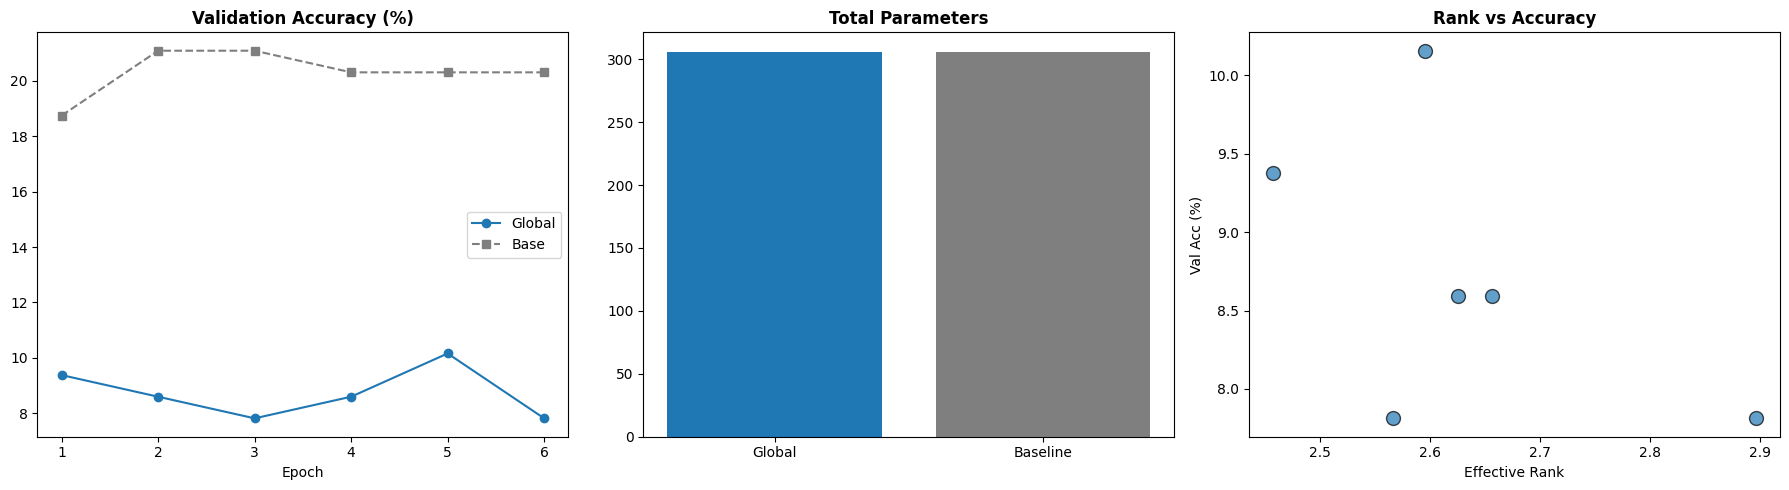

In [36]:
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display, Image # This forces it to show in VS Code/Jupyter

def plot_and_save_benchmark(history_lfp, history_base, model_lfp, model_base, folder=None):
    epochs = range(1, len(history_lfp["acc"]) + 1)
    
    # --- PLOT 1: Performance & Parameters ---
    fig1, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Val Accuracy
    axes[0].plot(epochs, [a * 100 for a in history_lfp["acc"]], 'o-', label="Global", color='#1f77b4')
    axes[0].plot(epochs, [a * 100 for a in history_base["acc"]], 's--', label="Base", color='#7f7f7f')
    axes[0].set_title("Validation Accuracy (%)", fontweight='bold')
    axes[0].set_xlabel("Epoch")
    axes[0].legend()

    # Params
    axes[1].bar(["Global", "Baseline"], [model_lfp.count_params(), model_base.count_params()], color=['#1f77b4', '#7f7f7f'])
    axes[1].set_title("Total Parameters", fontweight='bold')

    # Rank vs Acc Correlation
    ranks = [m.get('effective_rank', 0) for m in history_lfp["hidden_metrics"]]
    accs = [a * 100 for a in history_lfp["acc"]]
    axes[2].scatter(ranks, accs, color='#1f77b4', s=100, edgecolors='black', alpha=0.7)
    axes[2].set_title("Rank vs Accuracy", fontweight='bold')
    axes[2].set_xlabel("Effective Rank")
    axes[2].set_ylabel("Val Acc (%)")

    plt.tight_layout()
    path1 = 'thesis_performance_results.png' if folder is None else f"{folder}/performance_results.png"
    plt.savefig(path1, dpi=300)
    plt.show()  
    
# --- RUN IT ---
# If you have a variable folder name, pass it here
plot_and_save_benchmark(history_lfp, history_base, model_global, model_passive)

## Probing

In [57]:
class ProbingGlobalFieldCell(tf.keras.layers.Layer):
    def __init__(self, units=128, strength=0.1, lambda_slow=0.01, mode="modulate", **kwargs):
        super().__init__(**kwargs)
        self.units = units
        self.state_size = [units, units]
        self.strength = strength
        self.lambda_slow = lambda_slow
        self.mode = mode # "probe" or "modulate"

    def build(self, input_shape):
        self.w_in = self.add_weight(shape=(input_shape[-1], self.units), initializer="glorot_uniform")
        self.w_rec = self.add_weight(shape=(self.units, self.units), 
                                     initializer=tf.keras.initializers.Orthogonal(gain=1.0))
        self.bias = self.add_weight(shape=(self.units,), initializer="zeros")

    def call(self, inputs, states):
        prev_h, prev_G = states
        
        # 1. Field Update (The Probe)
        half = self.units // 2
        shifted_h = tf.concat([prev_h[:, half:], prev_h[:, :half]], axis=1)
        new_G = (1.0 - self.lambda_slow) * prev_G + self.lambda_slow * shifted_h
        
        # 2. Normalization (Always run to keep metrics consistent)
        G_norm = (new_G - tf.reduce_mean(new_G, axis=-1, keepdims=True)) / (tf.math.reduce_std(new_G, axis=-1, keepdims=True) + 1e-6)
        
        # 3. Decision Point: Decouple vs Modulate
        if self.mode == "probe":
            field_effect = 1.0  # Decoupled: Observe only
        else:
            field_effect = 1.0 + (self.strength * tf.tanh(G_norm)) # Modulatory
            
        # 4. Neural Update
        z = tf.matmul(inputs, self.w_in) + tf.matmul(prev_h, self.w_rec) + self.bias
        h_activated = tf.nn.leaky_relu(z * field_effect, alpha=0.1)
        h = (0.3 * prev_h) + (0.7 * h_activated)
        
        return h, [h, new_G]

# --- THE UPDATED CELL ---
class ProbingGlobalFieldCell(tf.keras.layers.Layer):
    def __init__(self, units=128, strength=0.1, lambda_slow=0.01, mode="modulate", **kwargs):
        super().__init__(**kwargs)
        self.units = units
        self.state_size = [units, units]
        self.strength = strength
        self.lambda_slow = lambda_slow
        self.mode = mode # "probe" or "modulate"

    def build(self, input_shape):
        self.w_in = self.add_weight(shape=(input_shape[-1], self.units), initializer="glorot_uniform")
        self.w_rec = self.add_weight(shape=(self.units, self.units), 
                                     initializer=tf.keras.initializers.Orthogonal(gain=1.0))
        self.bias = self.add_weight(shape=(self.units,), initializer="zeros")

    def call(self, inputs, states):
        prev_h, prev_G = states
        
        # 1. Field Update (The Probe - always happens)
        half = self.units // 2
        shifted_h = tf.concat([prev_h[:, half:], prev_h[:, :half]], axis=1)
        new_G = (1.0 - self.lambda_slow) * prev_G + self.lambda_slow * shifted_h
        
        # 2. Normalization
        G_norm = (new_G - tf.reduce_mean(new_G, axis=-1, keepdims=True)) / (tf.math.reduce_std(new_G, axis=-1, keepdims=True) + 1e-6)
        
        # 3. Decision Point: Decouple (Probe) vs Modulate
        # If probing, the field exists but the multiplier is invisible to the neuron
        if self.mode == "probe":
            field_effect = 1.0  
        else:
            field_effect = 1.0 + (self.strength * tf.tanh(G_norm))
            
        # 4. Neural Update
        z = tf.matmul(inputs, self.w_in) + tf.matmul(prev_h, self.w_rec) + self.bias
        h_candidate = z * field_effect
        h_activated = tf.nn.leaky_relu(h_candidate, alpha=0.1)
        
        # Standard Leaky Integration
        h = (0.3 * prev_h) + (0.7 * h_activated)
        
        return h, [h, new_G]

# --- THE UPDATED WRAPPER ---
class HierarchicalGlobalNet(tf.keras.Model):
    def __init__(self, hidden=128, num_classes=10, strength=0.1, lambda_slow=0.01, mode="modulate", use_lfp=True):
        super().__init__()
        self.use_lfp = use_lfp
        # PASSING MODE DOWN TO THE CELL
        self.rnn1 = tf.keras.layers.RNN(
            ProbingGlobalFieldCell(hidden, strength=strength, lambda_slow=lambda_slow, mode=mode), 
            return_sequences=True
        )
        self.rnn2 = tf.keras.layers.RNN(
            ProbingGlobalFieldCell(hidden, strength=strength, lambda_slow=lambda_slow, mode=mode), 
            return_sequences=True
        )
        self.out = tf.keras.layers.Dense(num_classes, dtype='float32')

    def call(self, x, training=False):
        h1_seq = self.rnn1(x, training=training)
        h2_seq = self.rnn2(h1_seq, training=training)
        logits = self.out(h2_seq[:, -1, :])
        return logits, h2_seq if self.use_lfp else None
    
def compute_lfp_metrics(h_seq_np, strength=0.0):
    h_final = np.nan_to_num(h_seq_np[:, -1, :])
    
    # 1. Effective Rank
    s = scipy.linalg.svdvals(h_final)
    p = s / (np.sum(s) + 1e-10)
    eff_rank = np.exp(-np.sum(p * np.log(p + 1e-10)))

    # 2. Synchrony
    corr_matrix = np.nan_to_num(np.corrcoef(h_final.T))
    sync = (np.sum(np.abs(corr_matrix)) - h_final.shape[1]) / (h_final.shape[1]**2 - h_final.shape[1])

    # 3. Autocorrelation (A-Corr)
    h_t, h_prev = h_seq_np[:, 1:, :], h_seq_np[:, :-1, :]
    a_corr = np.mean([np.corrcoef(h_t[0, i], h_prev[0, i])[0, 1] for i in range(min(5, h_t.shape[1]))])

    # 4. Log Interference (Intf)
    modulation_range = np.abs(strength) 
    intf = np.log10(modulation_range + 1e-8)

    # 5. Entropy
    counts, _ = np.histogram(h_final, bins=50)
    probs = counts / (np.sum(counts) + 1e-10)
    entropy = -np.sum(probs * np.log2(probs + 1e-10))

    return {
        "effective_rank": float(eff_rank), "synchrony": float(sync),
        "entropy": float(entropy), "a_corr": float(np.nan_to_num(a_corr)),
        "interference": float(intf)
    }

In [58]:
DATA_PERCENT = 0.1  
BATCH_SIZE = 128     
EPOCHS = 3
HIDDEN = 16
STRENGTH = -0.2

num_train = int(len(x_train) * DATA_PERCENT)
num_val   = int(len(x_val) * DATA_PERCENT)
num_test  = int(len(x_test) * DATA_PERCENT)

train_ds_subset = tf.data.Dataset.from_tensor_slices((x_train[:num_train], y_train[:num_train])) \
    .shuffle(5000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

val_ds_subset = tf.data.Dataset.from_tensor_slices((x_val[:num_val], y_val[:num_val])) \
    .batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

test_ds_subset = tf.data.Dataset.from_tensor_slices((x_test[:num_test], y_test[:num_test])) \
    .batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print(f"Test Run Ready: Samples -> Train: {num_train}, Val: {num_val}")

# --- 2. THE UPDATED TRAIN_MODEL_TF FUNCTION ---
def train_model_tf(model, train_data, val_data, epochs=2, lr=1e-3):
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr)
    loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
    
    @tf.function(jit_compile=False)
    def local_train_step(x, y):
        with tf.GradientTape() as tape:
            logits, h_seq = model(x, training=True)
            loss = loss_fn(y, logits)

        # Calculate live rank proxy for the tqdm bar
        h_final = h_seq[:, -1, :]
        live_var = tf.reduce_mean(tf.math.reduce_std(h_final, axis=-1))

        grads = tape.gradient(loss, model.trainable_variables)
        grads = [tf.clip_by_norm(g, 1.0) for g in grads]
        optimizer.apply_gradients(zip(grads, model.trainable_variables))
        
        # RETURNS 3 VALUES
        return loss, logits, live_var

    # 1. Warm-up (Fixed unpacking)
    print("Initializing Model...")
    for x_init, y_init in train_data.take(1):
        _, _, _ = local_train_step(x_init[:1], y_init[:1])
    
    history = {"loss": [], "acc": [], "hidden_metrics": []}
    
    # 2. Training Loop
    for epoch in range(epochs):
        train_acc_metric = tf.keras.metrics.SparseCategoricalAccuracy()
        pbar = tqdm(train_data, desc=f"Epoch {epoch+1}")
        
        for x_batch, y_batch in pbar:
            
            loss_val, logits, var_val = local_train_step(x_batch, y_batch)
            
            train_acc_metric.update_state(y_batch, logits)
            
            # Update TQDM with the live rank variance
            pbar.set_postfix({
                "loss": f"{loss_val.numpy():.4f}", 
                "acc": f"{train_acc_metric.result().numpy():.4f}",
                "rank_v": f"{var_val.numpy():.4f}"
            })

        # 3. Validation Snapshot
        for x_v, y_v in val_data.take(1):
            logits_v, h_seq_v = model(x_v, training=False)
            metrics = compute_lfp_metrics(h_seq_v.numpy())
            val_acc = np.mean(np.argmax(logits_v.numpy(), axis=-1) == y_v.numpy())
            
            history["loss"].append(loss_val.numpy())
            history["acc"].append(val_acc)
            history["hidden_metrics"].append(metrics)
            
            print(f" [Snapshot] Val_Acc: {val_acc:.4f} | Rank: {metrics['effective_rank']:.2f} | Sync: {metrics['synchrony']:.3f}")
            
    return history

# PHASE 1: THE PROBE (GF is present but decoupled)
# This maps how the GF correlates with activity WITHOUT influencing it.
print("\n[Phase 1] Probing GF Dynamics (Decoupled)...")
model_probe = HierarchicalGlobalNet(hidden=HIDDEN, strength=STRENGTH, mode="probe") 
history_probe = train_model_tf(model_probe, train_ds_subset, val_ds_subset, epochs=EPOCHS)

# VRAM Management: Clear memory
print("\nCleaning VRAM for next model...")
tf.keras.backend.clear_session()
gc.collect()

# PHASE 2: THE PASSIVE BASELINE (Pure RNN)
print("\n[Phase 2] Training Pure Passive Baseline...")
model_passive = HierarchicalGlobalNet(hidden=HIDDEN, strength=0.0, mode="modulate") 
history_base = train_model_tf(model_passive, train_ds_subset, val_ds_subset, epochs=EPOCHS)

# VRAM Management: Clear memory
print("\nCleaning VRAM for next model...")
tf.keras.backend.clear_session()
gc.collect()

# PHASE 3: THE MODULATOR (Controlled Influence)
print("\n[Phase 3] Activating GF as Modulator...")
model_active = HierarchicalGlobalNet(hidden=HIDDEN, strength=STRENGTH, mode="modulate")
history_active = train_model_tf(model_active, train_ds_subset, val_ds_subset, epochs=EPOCHS)


# 1. Evaluate models on the actual Test Set
print("Final Evaluation on Test Set...")
test_acc_probe = np.mean([np.mean(np.argmax(model_probe(x, training=False)[0].numpy(), axis=-1) == y.numpy()) for x, y in test_ds_subset])
test_acc_passive = np.mean([np.mean(np.argmax(model_passive(x, training=False)[0].numpy(), axis=-1) == y.numpy()) for x, y in test_ds_subset])
test_acc_active = np.mean([np.mean(np.argmax(model_active(x, training=False)[0].numpy(), axis=-1) == y.numpy()) for x, y in test_ds_subset])


# --- Summary Comparison ---
print_history_summary(history_probe, model_probe, "PROBE (DECOUPLED)", test_acc=test_acc_probe)
print_history_summary(history_base, model_passive, "PASSIVE BASELINE",test_acc=test_acc_passive)
print_history_summary(history_active, model_active, "ACTIVE MODULATOR",test_acc=test_acc_active)

Test Run Ready: Samples -> Train: 5400, Val: 600

[Phase 1] Probing GF Dynamics (Decoupled)...
Initializing Model...


Epoch 1: 100%|██████████| 43/43 [00:43<00:00,  1.00s/it, loss=2.2629, acc=0.1293, rank_v=0.0615]


 [Snapshot] Val_Acc: 0.0938 | Rank: 5.24 | Sync: 0.444


Epoch 2: 100%|██████████| 43/43 [01:04<00:00,  1.50s/it, loss=2.2870, acc=0.2056, rank_v=0.1338]


 [Snapshot] Val_Acc: 0.2031 | Rank: 5.99 | Sync: 0.514


...

 [Snapshot] Val_Acc: 0.1797 | Rank: 4.49 | Sync: 0.501


Epoch 2: 100%|██████████| 43/43 [01:46<00:00,  2.48s/it, loss=2.2494, acc=0.1728, rank_v=0.1652]


 [Snapshot] Val_Acc: 0.2344 | Rank: 4.59 | Sync: 0.566


Epoch 3: 100%|██████████| 43/43 [02:02<00:00,  2.85s/it, loss=2.0594, acc=0.1920, rank_v=0.4272]


 [Snapshot] Val_Acc: 0.2734 | Rank: 4.89 | Sync: 0.504
Final Evaluation on Test Set...

 DATA LOG: PROBE (DECOUPLED)
 CONFIG: Hidden: 16 | Params: 986 | Field Weight: -0.2000 | Lambda Slow (τ): 0.0100 | Data: 5.0%
Epoch  | Loss    | Val-Acc% | Rank   | Sync   | Entrp  | A-Corr  | Intf   | F-Wgt 
--------------------------------------------------------------------------------------------------------------------------------------------
1      | 2.263   | 9.38     | 5.24   | 0.444  | 4.35   | 0.776   | -8.000 | -0.200
2      | 2.287   | 20.31    | 5.99   | 0.514  | 4.48   | 0.954   | -8.000 | -0.200
3      | 2.231   | 23.44    | 4.98   | 0.642  | 4.72   | 0.962   | -8.000 | -0.200
--------------------------------------------------------------------------------------------------------------------------------------------
 FINAL PERFORMANCE: Validation Acc: 23.44% | TEST ACCURACY: 28.53%
 FINAL DYNAMICS   : Rank: 4.98 | Entropy: 4.72 | Synchrony: 0.642


 DATA LOG: PASSIVE BASELINE
 CONFIG: 